# Telco Customer Churn: Exploratory Data Analysis

## Author

Seth Alvarez

## Collaborator

Claude (Anthropic) - for organization and checking my code

## Course: Intro to Machine Learning (ITAI 1371), Houston Community College

This notebook is my contribution to a group midterm project. My job was to look at training data of a telecom churn dataset before anyone cleans or changes it. I then find the data problems and the patterns to suggest later steps for my group members.

## Dataset

- **Name:** Customers churned in telecom services
- **Source:** [Kaggle](https://www.kaggle.com/datasets/kapturovalexander/customers-churned-in-telecom-services)
- **Size:** 7,043 rows and 20 columns
- **Target:** `Churn` (Yes or No)
- **License:** CC0 Public Domain

The dataset is not in this repository. To run this notebook, download `customer_churn_telecom_services.csv` from the Kaggle link and put it in the same folder as the notebook. In Google Colab, upload it to the session storage.

## Setup

This cell loads the libraries and makes a `results` folder for the charts.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# This makes the folder where each chart is saved as a PNG file.
os.makedirs("results", exist_ok=True)

## Load the Data and Split It

Group member Diane Lenhoff wrote the 70/30 split for my group's midterm notebook. This cell uses her split settings (`test_size=0.30`, `random_state=42`, stratified on `Churn`), so my EDA runs on the same training set as the group's.

The data is split before any analysis is done, and all of the EDA below uses the training set only, so the test set stays unseen and can give a fair check of a model later. `stratify` keeps the same share of churned customers in both sets.

In [ ]:
# This loads the dataset from the CSV file.
df = pd.read_csv("customer_churn_telecom_services.csv")
print("Dataset shape:", df.shape)

# This splits the data into 70% training and 30% testing with the same churn ratio in each set.
train_data, test_data = train_test_split(df, test_size=0.30, random_state=42, stratify=df["Churn"])
print("Training set:", train_data.shape)
print("Testing set:", test_data.shape)

Dataset shape: (7043, 20)
Training set: (4930, 20)
Testing set: (2113, 20)


## Step 1: Structure of the Training Data

I start with the size of the training set and the data type of each column. The non-null count shows which columns have missing values.

**What I found:** TotalCharges has 4,923 values out of 4,930, so 7 are missing. Only three columns are numeric (tenure, MonthlyCharges and TotalCharges). SeniorCitizen is stored as a number but it is a 0 or 1 category.

In [ ]:
# Step 1: Structure of the training data
# This shows the number of rows and columns in the training set.
print("Training data shape:", train_data.shape)
print()

# This shows each column's name, data type, and non-null count.
train_data.info()

Training data shape: (4930, 20)

<class 'pandas.core.frame.DataFrame'>
Index: 4930 entries, 5557 to 5639
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            4930 non-null   object 
 1   SeniorCitizen     4930 non-null   int64  
 2   Partner           4930 non-null   object 
 3   Dependents        4930 non-null   object 
 4   tenure            4930 non-null   int64  
 5   PhoneService      4930 non-null   object 
 6   MultipleLines     4930 non-null   object 
 7   InternetService   4930 non-null   object 
 8   OnlineSecurity    4930 non-null   object 
 9   OnlineBackup      4930 non-null   object 
 10  DeviceProtection  4930 non-null   object 
 11  TechSupport       4930 non-null   object 
 12  StreamingTV       4930 non-null   object 
 13  StreamingMovies   4930 non-null   object 
 14  Contract          4930 non-null   object 
 15  PaperlessBilling  4930 non-null   object 
 16  PaymentMeth

## Step 2: Summary Statistics for the Numeric Columns

`describe()` gives the mean, the spread and the quartiles for the three numeric columns.

**What I found:** The mean of TotalCharges (2,305) is much higher than its median (1,389), which means a few very high values pull the mean up. The ranges are also very different, since tenure stops at 72 and TotalCharges goes up to 8,685.

In [ ]:
# Step 2: Summary statistics for numeric features
# SeniorCitizen is only 0 or 1, so we treat it as a category.
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# This shows the count, mean, standard deviation, minimum, quartiles, and maximum.
print("Summary statistics (numeric features):")
print(train_data[numeric_features].describe().round(2))

Summary statistics (numeric features):
        tenure  MonthlyCharges  TotalCharges
count  4930.00         4930.00       4923.00
mean     32.47           64.95       2305.07
std      24.65           30.24       2292.55
min       0.00           18.40         18.85
25%       9.00           35.50        399.80
50%      29.00           70.57       1389.20
75%      56.00           90.05       3860.30
max      72.00          118.75       8684.80


## Step 3: Counts for the Categorical Columns

This counts each category in each of the 16 categorical columns. It shows spelling problems and how many categories each column has, which decides how to encode it later.

**What I found:** The labels are clean and no column has more than 4 categories. "No internet service" shows 1,068 times in six columns, which repeats what `InternetService = No` already says.

In [ ]:
# Step 3: Summary statistics for categorical features
# This selects all columns that are not numeric and are not the target (Churn).
categorical_features = [col for col in train_data.columns
                        if col not in numeric_features + ["Churn"]]

# This counts each category in each column.
for col in categorical_features:
    print(f"--- {col} ---")
    print(train_data[col].value_counts())
    print()

--- gender ---
gender
Male      2478
Female    2452
Name: count, dtype: int64

--- SeniorCitizen ---
SeniorCitizen
0    4136
1     794
Name: count, dtype: int64

--- Partner ---
Partner
No     2558
Yes    2372
Name: count, dtype: int64

--- Dependents ---
Dependents
No     3463
Yes    1467
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    4434
No      496
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  2347
Yes                 2087
No phone service     496
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    2177
DSL            1685
No             1068
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     2439
Yes                    1423
No internet service    1068
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     2142
Yes                    1720
No internet service    1068
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtect

## Step 4: Churn Distribution

Churn is the target, so I check how many customers are in each class.

**What I found:** 73.5% of customers stayed and 26.5% left. A model that always guesses No is right 73.5% of the time, so accuracy alone isn't enough to tell if a model is good.

Churn counts:
Churn
No     3622
Yes    1308
Name: count, dtype: int64

Churn percentages:
Churn
No     73.47
Yes    26.53
Name: proportion, dtype: float64


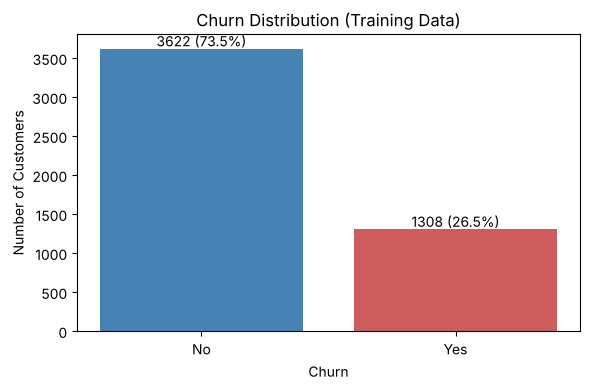

In [ ]:
# Step 4: Target variable distribution (Churn)
# This counts the customers in each class as numbers and percentages.
churn_counts = train_data["Churn"].value_counts()
churn_pct = train_data["Churn"].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)
print("\nChurn percentages:")
print(churn_pct.round(2))

# This shows a bar chart of the two classes, which is also the "before" chart for class balancing.
plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values, color=["steelblue", "indianred"])
plt.title("Churn Distribution (Training Data)")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 30, f"{v} ({churn_pct.values[i]:.1f}%)", ha="center")
plt.tight_layout()
plt.savefig("results/churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5: Distributions of the Numeric Columns

A histogram shows the shape of each numeric column, and skewness gives that shape as one number.

**What I found:** The two biggest groups of customers are brand new ones and ones who have stayed about 72 months. MonthlyCharges has a big group near 20. Most TotalCharges values are low and only a few are very high (skewness 0.95).

Skewness (0 = balanced, > 0 = right-skewed, < 0 = left-skewed):
tenure            0.24
MonthlyCharges   -0.22
TotalCharges      0.95
dtype: float64


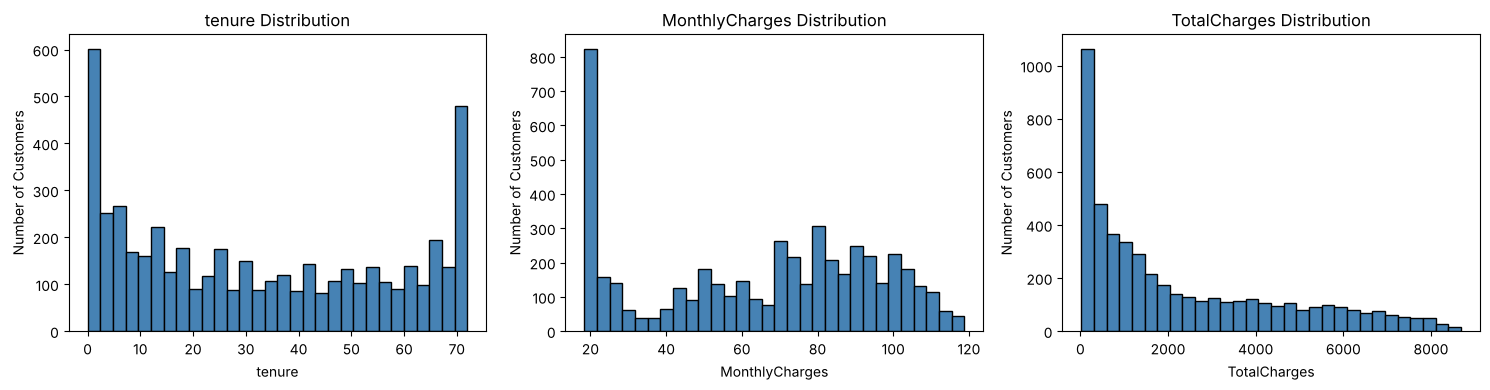

In [ ]:
# Step 5: Distributions of numeric features
# This shows the skewness of each column. Near 0 means balanced, above 0 means right-skewed.
print("Skewness (0 = balanced, > 0 = right-skewed, < 0 = left-skewed):")
print(train_data[numeric_features].skew().round(2))

# This shows a histogram for each numeric column. dropna() skips the 7 missing TotalCharges values.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_features):
    axes[i].hist(train_data[col].dropna(), bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("results/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 6: Numeric Columns by Churn

These box plots compare customers who stayed with customers who left.

**What I found:** Customers who left stayed a shorter time (median 10 months compared to 38) and paid more each month (median 80 compared to 64).

Median values by Churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.45       1679.40
Yes      10.0           80.00        705.08


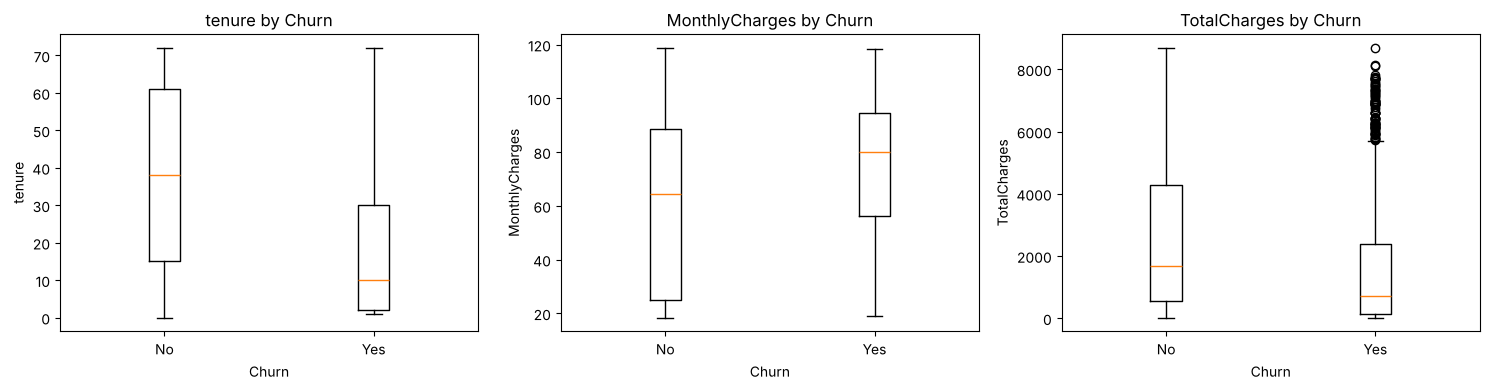

In [ ]:
# Step 6: Numeric features compared by Churn
# This shows the median of each numeric column for customers who stayed and who left.
print("Median values by Churn:")
print(train_data.groupby("Churn")[numeric_features].median().round(2))

# This shows a box plot of each numeric column, split by Churn.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_features):
    data_no = train_data.loc[train_data["Churn"] == "No", col].dropna()
    data_yes = train_data.loc[train_data["Churn"] == "Yes", col].dropna()
    axes[i].boxplot([data_no, data_yes], tick_labels=["No", "Yes"])
    axes[i].set_title(f"{col} by Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.savefig("results/numeric_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7: Churn Rate for Each Category

For each categorical column, this shows the percent of customers who left in each category.

**What I found:** Churn is highest for month-to-month contracts (42.9%), electronic check (45.6%) and fiber optic (41.8%). Customers with no OnlineSecurity or TechSupport leave at about 42%. Men and women leave at about the same rate.

--- Churn rate (%) by gender ---
gender
Female    26.3
Male      26.8

--- Churn rate (%) by SeniorCitizen ---
SeniorCitizen
0    23.7
1    41.1

--- Churn rate (%) by Partner ---
Partner
No     32.9
Yes    19.6

--- Churn rate (%) by Dependents ---
Dependents
No     31.5
Yes    14.9

--- Churn rate (%) by PhoneService ---
PhoneService
No     23.4
Yes    26.9

--- Churn rate (%) by MultipleLines ---
MultipleLines
No                  25.1
No phone service    23.4
Yes                 28.9

--- Churn rate (%) by InternetService ---
InternetService
DSL            19.2
Fiber optic    41.8
No              6.9

--- Churn rate (%) by OnlineSecurity ---
OnlineSecurity
No                     42.0
No internet service     6.9
Yes                    14.7

--- Churn rate (%) by OnlineBackup ---
OnlineBackup
No                     40.3
No internet service     6.9
Yes                    21.6

--- Churn rate (%) by DeviceProtection ---
DeviceProtection
No                     39.2
No internet service   

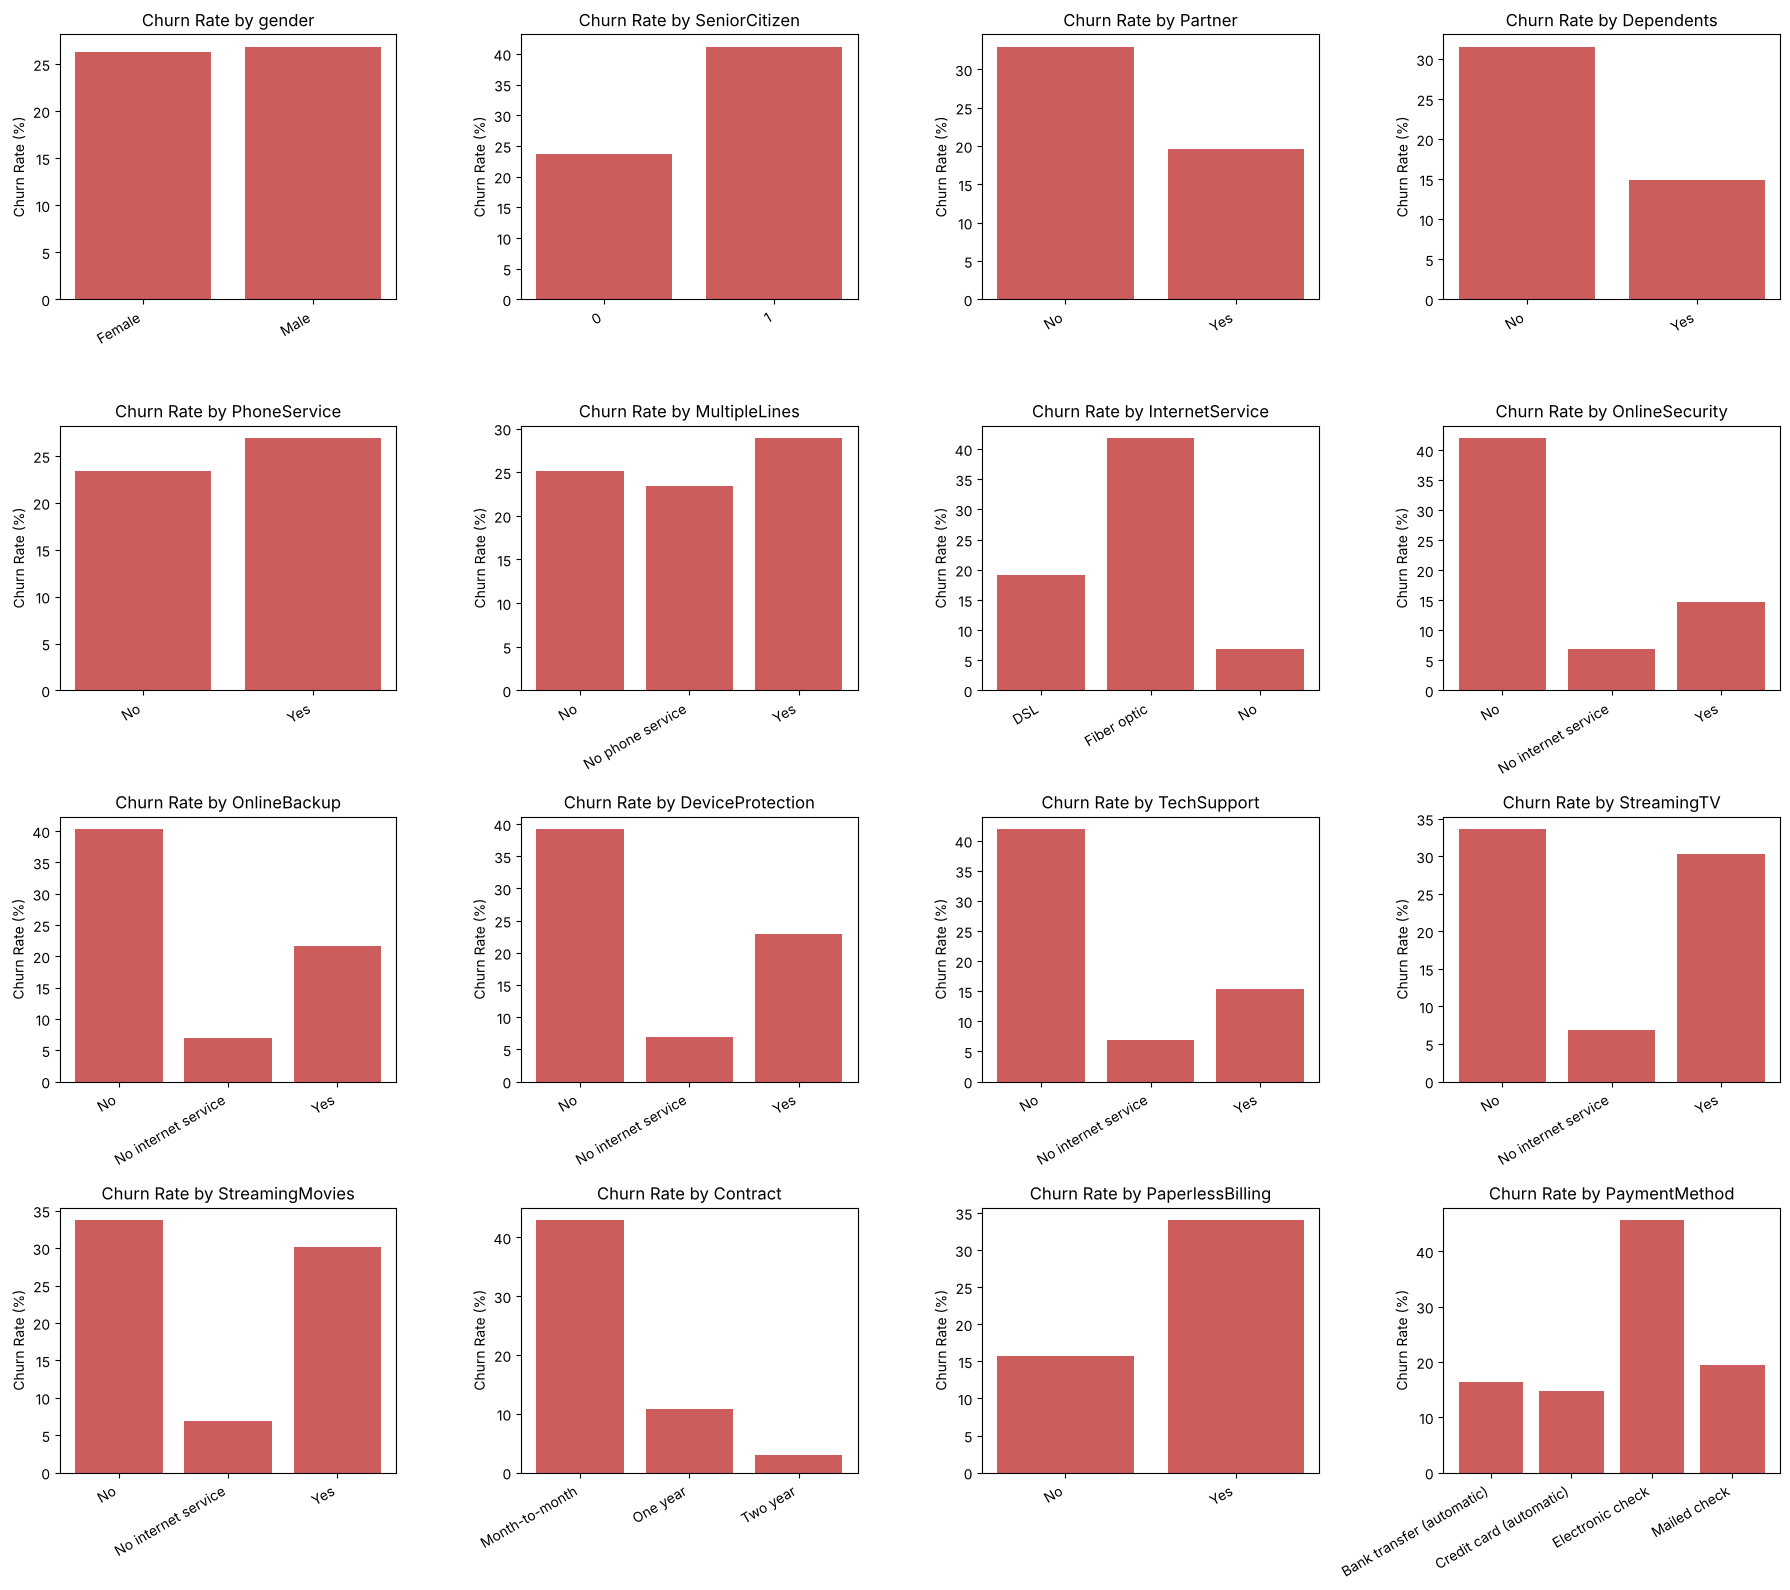

In [ ]:
# Step 7: Churn rate for each categorical feature
# This shows the percent of customers who left in each category, as text and as a 4 x 4 chart grid.
churn_flag = train_data["Churn"] == "Yes"
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for ax, col in zip(axes.flatten(), categorical_features):
    rates = (churn_flag.groupby(train_data[col]).mean() * 100).round(1)
    print(f"--- Churn rate (%) by {col} ---\n{rates.to_string()}\n")
    ax.bar(rates.index.astype(str), rates.values, color="indianred")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig("results/churn_rate_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Correlation Between the Numeric Columns

The correlation shows which numeric columns go up and down together.

**What I found:** tenure and TotalCharges have a correlation of 0.83. That makes sense, because a customer who stays longer pays more in total.

Correlation matrix:
                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.26          0.83
MonthlyCharges    0.26            1.00          0.65
TotalCharges      0.83            0.65          1.00


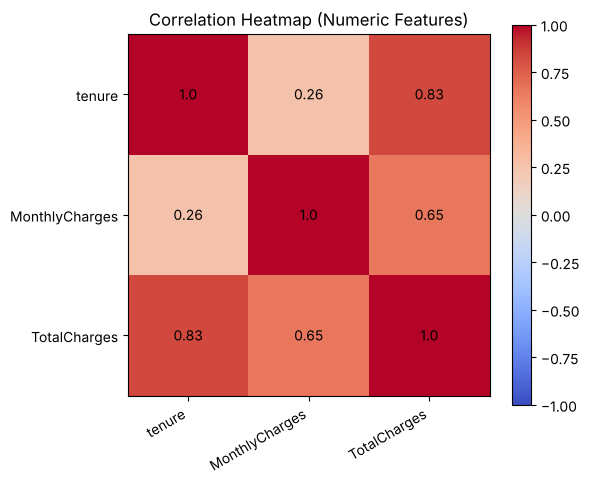

In [ ]:
# Step 8: Correlation between numeric features
# This shows how strongly each pair of numeric columns moves together, from -1 to 1.
corr = train_data[numeric_features].corr().round(2)
print("Correlation matrix:")
print(corr)

# This shows the matrix as a heatmap with each value written in its cell.
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_features)), numeric_features, rotation=30, ha="right")
ax.set_yticks(range(len(numeric_features)), numeric_features)
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center")
fig.colorbar(im)
ax.set_title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("results/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9: Missing Values and Duplicates

Finds the missing values and the duplicate rows. Cleaning them would be a later step not done here.

**What I found:** All 7 rows with a missing TotalCharges have a tenure of 0. These customers have no bill yet, so the right value is 0 and not the median. There are also 9 duplicate rows.

In [ ]:
# Step 9: Missing values and duplicates (found here, fixed in the cleaning section)
# This shows each column with missing values and the rows where TotalCharges is missing.
missing = train_data.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0])
print("\nRows with missing TotalCharges:")
print(train_data.loc[train_data["TotalCharges"].isnull(), ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

# This is the number of fully duplicated rows in the training set.
print("\nDuplicate rows:", train_data.duplicated().sum())

Columns with missing values:
TotalCharges    7
dtype: int64

Rows with missing TotalCharges:
      tenure  MonthlyCharges  TotalCharges Churn
6670       0           73.35           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
488        0           52.55           NaN    No
1082       0           25.75           NaN    No
6754       0           61.90           NaN    No
3331       0           19.85           NaN    No

Duplicate rows: 9


## Summary and Plan for the Next Steps

**Data quality**
- TotalCharges has 7 missing values, and all 7 rows have tenure = 0. These customers have no bill yet, so their TotalCharges should be 0.
- The training set has 9 duplicate rows and the data has no customer ID, so these could be different customers who happen to have the same values.
- The category labels are clean, with no spelling mistakes.

**Distributions**
- Most TotalCharges values are low and only a few are very high (skewness 0.95), so a log transform should even it out.
- The two biggest groups of customers are brand new ones and ones who have stayed about 72 months. MonthlyCharges has a big group near 20, which is customers with no internet.
- tenure only goes up to 72, but TotalCharges goes up to 8,685. These columns need scaling so that TotalCharges doesn't count more than tenure just because its numbers are bigger.

**Target**
- 73.5% of customers stayed and 26.5% left. The classes need balancing, but only on the training set.

**Churn patterns**
- Customers leave the most when they are on month-to-month contracts (42.9%), pay by electronic check (45.6%), have fiber optic (41.8%), or have no OnlineSecurity or TechSupport (about 42%).
- Customers who left stayed a shorter time (median 10 months compared to 38) and paid more each month (median 80 compared to 64).
- Men and women leave at about the same rate.
- tenure and TotalCharges go up together (correlation 0.83). This is under the 0.9 limit, so both columns stay.

**Encoding plan**
- Yes/No columns become 1 and 0.
- Contract goes from shortest to longest (Month-to-month, One year, Two year), so it gets label encoding.
- InternetService, PaymentMethod, MultipleLines and the internet add-on columns have no order, so they get one-hot encoding.
- SeniorCitizen is already 0 and 1, so it stays as is.

**Feature engineering ideas**
- Count how many protection and support services each customer has (OnlineSecurity, OnlineBackup, DeviceProtection and TechSupport).
- Group tenure into 0-12, 13-24, 25-48 and 49-72 months to show churn by how long someone has been a customer.

## Credits and AI Use

- **Dataset:** [Customers churned in telecom services](https://www.kaggle.com/datasets/kapturovalexander/customers-churned-in-telecom-services) by kapturovalexander on Kaggle, CC0 Public Domain.
- **Split:** Diane Lenhoff wrote the 70/30 split in my group's midterm notebook, and this notebook uses her settings.
- **AI use:** I used Claude (Anthropic) to help organize this notebook and check my code on Steps 7, and 8.